--- Step 1: Feature Engineering ---

--- Step 2: Chronological Split ---
Training rows: 10694
Testing rows: 168

--- Step 3: Training Models ---

--- Step 4: Evaluation ---
Metrics for Random Forest:
  RMSE: 34.95
  MAE:  20.73
Metrics for XGBoost:
  RMSE: 30.42
  MAE:  19.73

--- Step 5: Visualizing Results ---


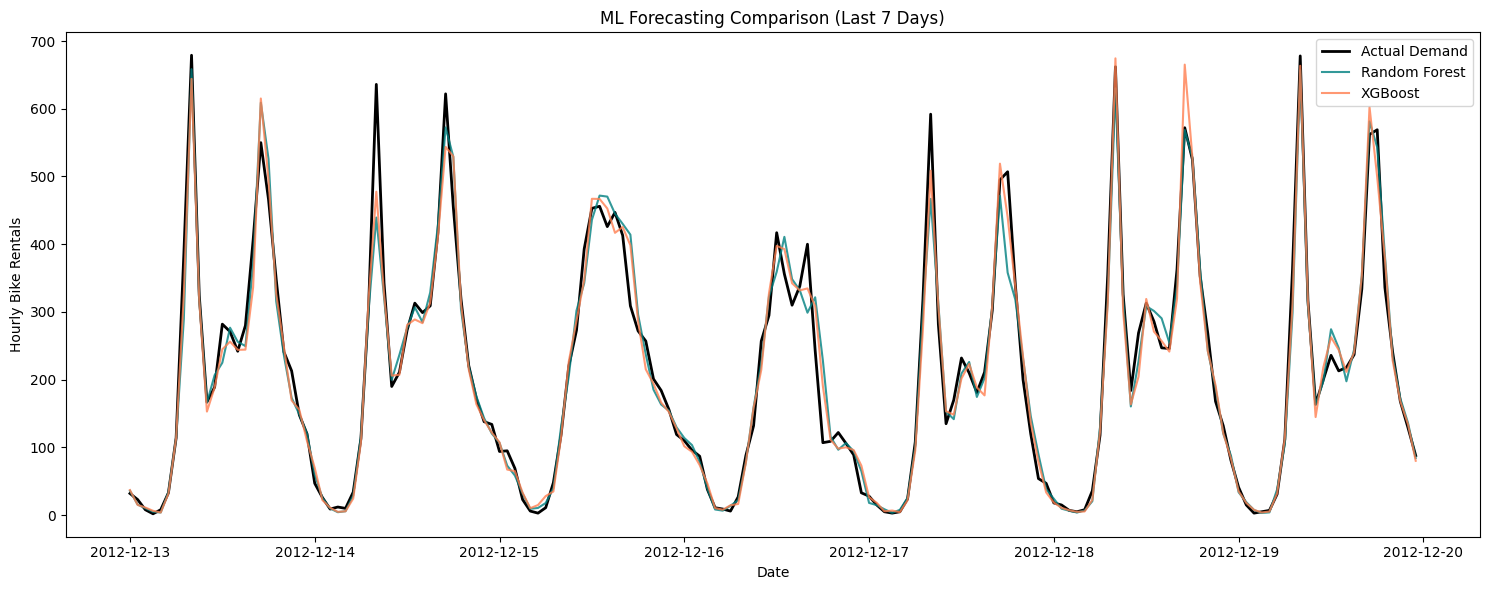

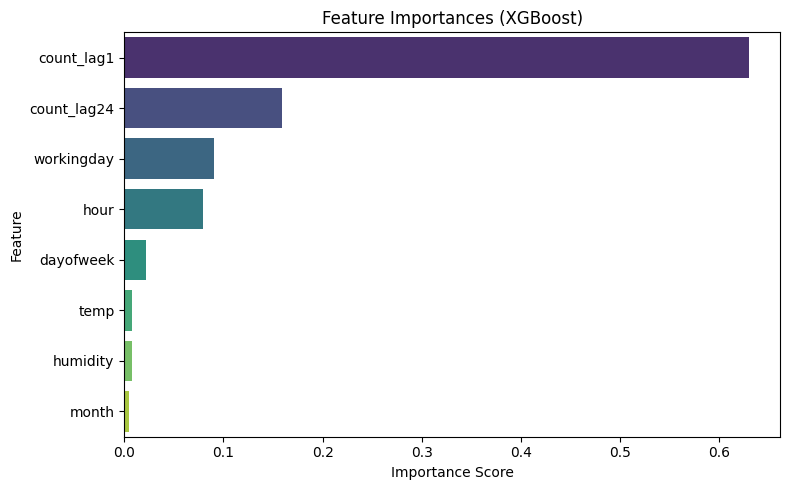

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

# ==========================================
# Step 1: Data Preparation & Feature Engineering
# ==========================================
print("--- Step 1: Feature Engineering ---")
if not os.path.exists("train.csv"):
    raise FileNotFoundError("🛑 STOP! 'train.csv' is missing.")

# Load data without setting datetime as the index yet
df = pd.read_csv("train.csv", parse_dates=["datetime"])

# Extract temporal features explicitly
df['hour'] = df['datetime'].dt.hour
df['dayofweek'] = df['datetime'].dt.dayofweek
df['month'] = df['datetime'].dt.month

# Create lagged features (recreating the AR behavior)
df['count_lag1'] = df['count'].shift(1)
df['count_lag24'] = df['count'].shift(24)

# Drop the rows with NaNs caused by shifting (the first 24 hours)
df_clean = df.dropna().copy()

# Define our features (X) and target (y)
# Notice we can now easily include weather data!
features = ['hour', 'dayofweek', 'month', 'temp', 'humidity', 'workingday', 'count_lag1', 'count_lag24']
X = df_clean[features]
y = df_clean['count']

# ==========================================
# Step 2: Chronological Train/Test Split
# ==========================================
print("\n--- Step 2: Chronological Split ---")
test_size = 168 # Last 7 days (7 * 24 hours)

# Strictly sequential split! No random_state shuffling!
X_train, X_test = X.iloc[:-test_size], X.iloc[-test_size:]
y_train, y_test = y.iloc[:-test_size], y.iloc[-test_size:]
datetime_test = df_clean['datetime'].iloc[-test_size:] # Keep for plotting

print(f"Training rows: {len(X_train)}")
print(f"Testing rows: {len(X_test)}")

# ==========================================
# Step 3: Train Machine Learning Models
# ==========================================
print("\n--- Step 3: Training Models ---")

# Random Forest
rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

# XGBoost
xgb = XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42, objective='reg:squarederror')
xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)

# ==========================================
# Step 4: Evaluation and Metrics
# ==========================================
print("\n--- Step 4: Evaluation ---")
def print_metrics(y_true, y_pred, model_name):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    print(f"Metrics for {model_name}:")
    print(f"  RMSE: {rmse:.2f}")
    print(f"  MAE:  {mae:.2f}")
    return rmse, mae

rmse_rf, mae_rf = print_metrics(y_test, y_pred_rf, "Random Forest")
rmse_xgb, mae_xgb = print_metrics(y_test, y_pred_xgb, "XGBoost")

# ==========================================
# Step 5: Visualizations
# ==========================================
print("\n--- Step 5: Visualizing Results ---")

# 1. Forecast Plot
plt.figure(figsize=(15, 6))
plt.plot(datetime_test, y_test.values, label='Actual Demand', color='black', linewidth=2)
plt.plot(datetime_test, y_pred_rf, label='Random Forest', color='teal', alpha=0.8)
plt.plot(datetime_test, y_pred_xgb, label='XGBoost', color='coral', alpha=0.8)
plt.title("ML Forecasting Comparison (Last 7 Days)")
plt.xlabel("Date")
plt.ylabel("Hourly Bike Rentals")
plt.legend()
plt.tight_layout()
plt.show()

# 2. Feature Importance Plot (XGBoost)
importances = pd.Series(xgb.feature_importances_, index=features).sort_values(ascending=False)
plt.figure(figsize=(8, 5))
sns.barplot(x=importances.values, y=importances.index, hue=importances.index, palette="viridis", legend=False)
plt.title("Feature Importances (XGBoost)")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()